In [2]:
import pandas as pd
import numpy as np

In [3]:
from pathlib import Path

data_path = Path("../data/raw")

sales = pd.read_csv(data_path / "sales_daily.csv")
sku = pd.read_csv(data_path / "sku_master.csv")
calendar = pd.read_csv(data_path / "calendar.csv")
inventory = pd.read_csv(data_path / "inventory_snapshots.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
print("SALES DAILY")
print("Shape:", sales.shape)
print("\nColumns:")
print(sales.columns.tolist())
print("\nData Types:")
print(sales.dtypes)

SALES DAILY
Shape: (146200, 6)

Columns:
['date', 'sku_id', 'units_sold', 'unit_price', 'promo_flag', 'revenue']

Data Types:
date           object
sku_id         object
units_sold      int64
unit_price    float64
promo_flag      int64
revenue       float64
dtype: object


In [5]:
sales.head()

,date,sku_id,units_sold,unit_price,promo_flag,revenue
0,2024-01-01,SKU0001,8,9251.86,0,74014.88
1,2024-01-02,SKU0001,0,9489.92,0,0.00
2,2024-01-03,SKU0001,11,9067.78,0,99745.58
3,2024-01-04,SKU0001,12,9237.25,0,110847.00
4,2024-01-05,SKU0001,9,9098.72,0,81888.48


In [6]:
print("Missing Values:")
print(sales.isnull().sum())

print("\nDuplicate Rows:")
print(sales.duplicated().sum())

print("\nBasic Statistics:")
sales.describe()

Missing Values:
date          0
sku_id        0
units_sold    0
unit_price    0
promo_flag    0
revenue       0
dtype: int64

Duplicate Rows:
0

Basic Statistics:


,units_sold,unit_price,promo_flag,revenue
count,146200.000000,146200.000000,146200.000000,146200.000000
mean,7.511012,8240.610173,0.129959,58712.114613
std,5.834612,5088.885099,0.336259,61896.409204
min,0.000000,512.460000,0.000000,0.000000
25%,3.000000,3595.835000,0.000000,16059.817500
50%,6.000000,7546.955000,0.000000,39090.210000
75%,10.000000,12323.240000,0.000000,80774.460000
max,64.000000,21602.900000,1.000000,673264.740000


In [7]:
print("Date Range:")
print("Start Date:", sales["date"].min())
print("End Date:", sales["date"].max())

print("\nUnique SKUs:")
print(sales["sku_id"].nunique())

print("\nPromo Distribution:")
print(sales["promo_flag"].value_counts())

print("\nZero Sales Days:")
print((sales["units_sold"] == 0).sum())

Date Range:
Start Date: 2024-01-01
End Date: 2025-12-31

Unique SKUs:
200

Promo Distribution:
promo_flag
0    127200
1     19000
Name: count, dtype: int64

Zero Sales Days:
6569


In [8]:
sku_demand = (
    sales.groupby("sku_id")["units_sold"]
    .agg(["sum", "mean", "max"])
    .sort_values("sum", ascending=False)
)

print("Top 10 SKUs by Total Units Sold:")
print(sku_demand.head(10))

Top 10 SKUs by Total Units Sold:
           sum       mean  max
sku_id                        
SKU0135  20021  27.388509   64
SKU0027  15970  21.846785   46
SKU0005  15308  20.941176   45
SKU0190  14770  20.205198   51
SKU0133  13591  18.592339   41
SKU0089  13582  18.580027   45
SKU0097  13270  18.153215   42
SKU0132  13203  18.061560   38
SKU0114  12651  17.306430   38
SKU0154  12497  17.095759   43


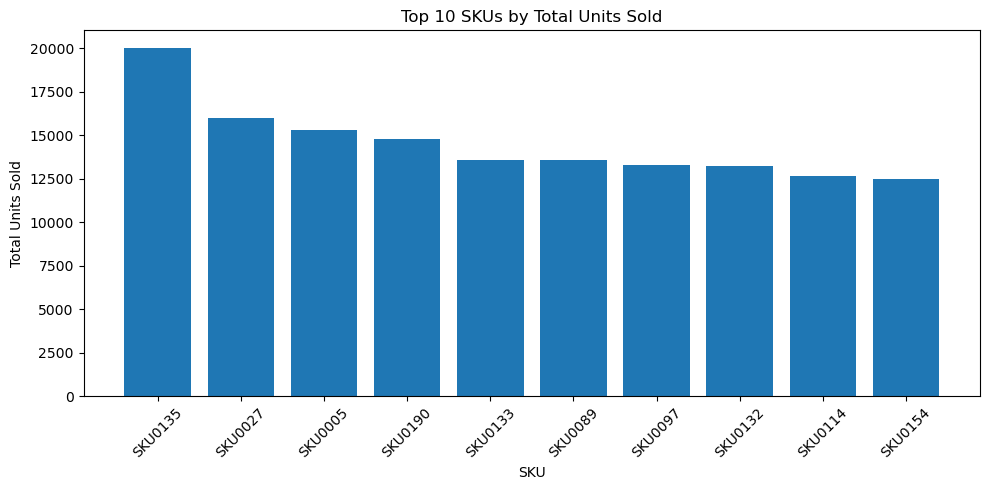

In [9]:
import matplotlib.pyplot as plt

top10 = sku_demand.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10.index, top10["sum"])
plt.xticks(rotation=45)
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.title("Top 10 SKUs by Total Units Sold")
plt.tight_layout()
plt.show()

In [10]:
promo_analysis = (
    sales.groupby("promo_flag")["units_sold"]
    .agg(["count", "mean", "sum"])
)

print(promo_analysis)

             count       mean     sum
promo_flag                           
0           127200   7.096431  902666
1            19000  10.286526  195444


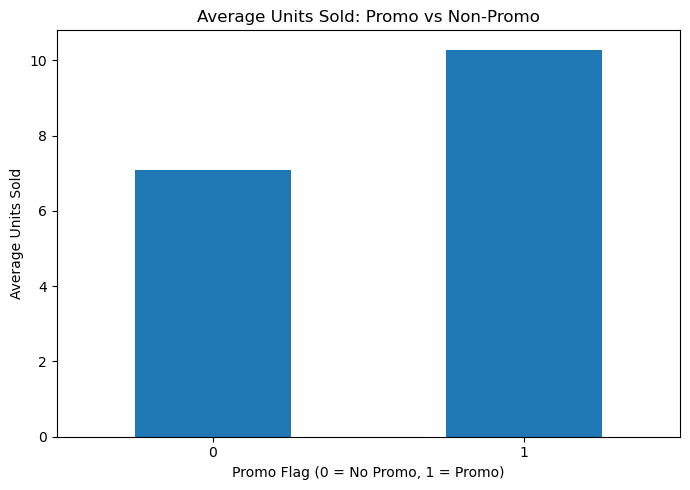

In [11]:
promo_analysis["mean"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Units Sold: Promo vs Non-Promo")
plt.xlabel("Promo Flag (0 = No Promo, 1 = Promo)")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
category_sales = sales.merge(
    sku[["sku_id", "category", "subcategory"]],
    on="sku_id",
    how="left"
)

category_demand = (
    category_sales
    .groupby("category")["units_sold"]
    .agg(["sum", "mean"])
    .sort_values("sum", ascending=False)
)

print("Category-wise Demand:")
print(category_demand)

Category-wise Demand:
                     sum      mean
category                          
Decor             339452  9.287332
Furniture         294174  8.048536
Small Appliances  247966  6.784295
Lighting          216518  5.923885


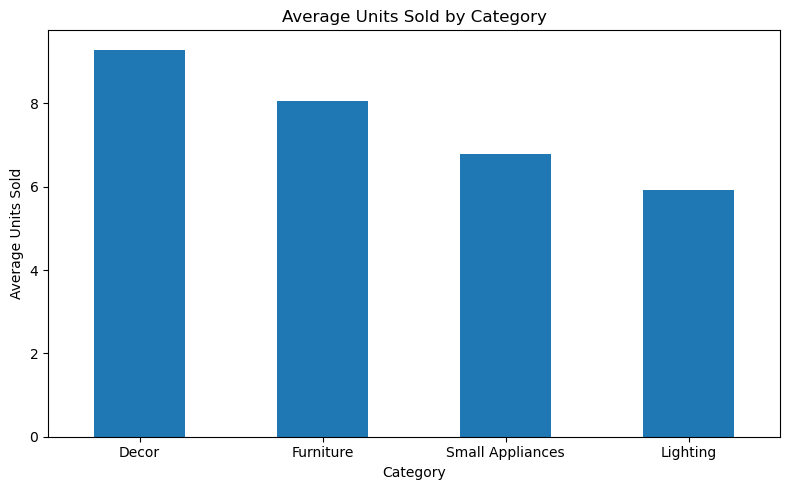

In [13]:
category_demand["mean"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Convert date to datetime
sales["date"] = pd.to_datetime(sales["date"])

# Monthly demand
monthly_demand = (
    sales.set_index("date")
    .resample("ME")["units_sold"]
    .sum()
)

print(monthly_demand)

date
2024-01-31    34709
2024-02-29    33208
2024-03-31    43080
2024-04-30    38923
2024-05-31    42245
2024-06-30    38577
2024-07-31    46300
2024-08-31    42866
2024-09-30    39233
2024-10-31    52018
2024-11-30    55928
2024-12-31    58332
2025-01-31    38002
2025-02-28    35137
2025-03-31    46796
2025-04-30    42717
2025-05-31    44944
2025-06-30    42045
2025-07-31    50422
2025-08-31    45884
2025-09-30    43379
2025-10-31    59573
2025-11-30    61647
2025-12-31    62145
Freq: ME, Name: units_sold, dtype: int64


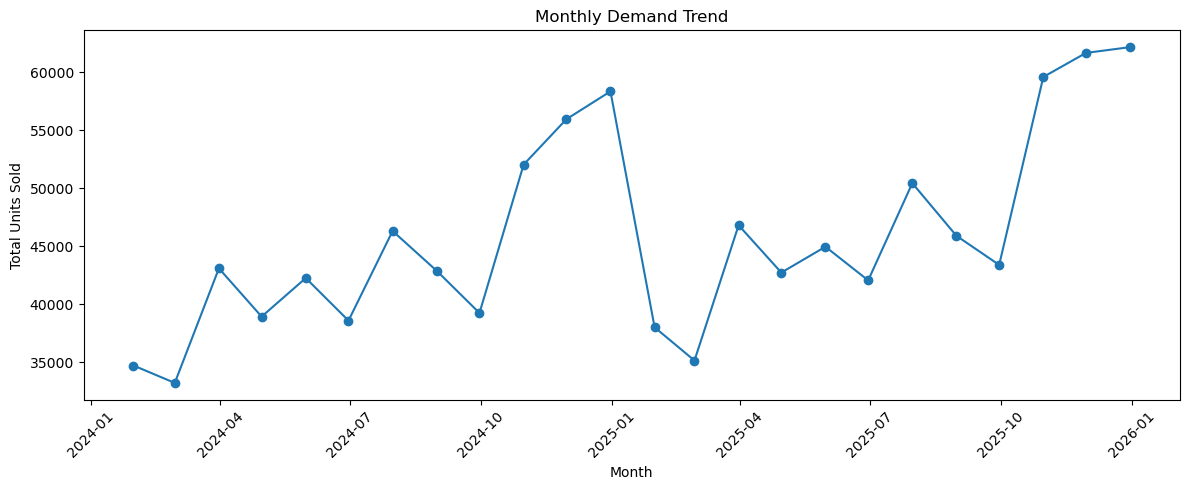

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
print("SKU MASTER")
print("Shape:", sku.shape)

print("\nColumns:")
print(sku.columns.tolist())

print("\nData Types:")
print(sku.dtypes)

print("\nMissing Values:")
print(sku.isnull().sum())

print("\nDuplicate Rows:")
print(sku.duplicated().sum())

SKU MASTER
Shape: (200, 6)

Columns:
['sku_id', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price']

Data Types:
sku_id          object
category        object
subcategory     object
launch_date     object
unit_cost      float64
list_price     float64
dtype: object

Missing Values:
sku_id         0
category       0
subcategory    0
launch_date    0
unit_cost      0
list_price     0
dtype: int64

Duplicate Rows:
0


In [17]:
print("Categories:")
print(sku["category"].value_counts())

print("\nSubcategories:")
print(sku["subcategory"].nunique())

print("\nPrice Statistics:")
print(sku[["unit_cost", "list_price"]].describe())

Categories:
category
Furniture           50
Decor               50
Small Appliances    50
Lighting            50
Name: count, dtype: int64

Subcategories:
20

Price Statistics:
         unit_cost    list_price
count   200.000000    200.000000
mean   4454.273500   8349.296750
std    2646.041762   5156.534054
min     357.650000    594.730000
25%    2011.852500   3737.155000
50%    4357.610000   7911.350000
75%    7021.440000  12486.317500
max    8992.170000  20685.900000


In [18]:
sku["launch_date"] = pd.to_datetime(sku["launch_date"])

print("Launch Date Range:")
print("First:", sku["launch_date"].min())
print("Last:", sku["launch_date"].max())

print("\nData Type:")
print(sku["launch_date"].dtype)

Launch Date Range:
First: 2024-01-04 00:00:00
Last: 2025-05-11 00:00:00

Data Type:
datetime64[ns]


In [19]:
sku["launch_date"] = pd.to_datetime(sku["launch_date"])

In [20]:
print("Inventory Shape:", inventory.shape)

print("\nMissing Values:")
print(inventory.isnull().sum())

print("\nDuplicate Rows:")
print(inventory.duplicated().sum())


Inventory Shape: (21000, 6)

Missing Values:
date              0
sku_id            0
on_hand_units     0
on_order_units    0
lead_time_days    0
reorder_point     0
dtype: int64

Duplicate Rows:
0


In [21]:
sales["date"] = pd.to_datetime(sales["date"])

daily_demand = (
    sales.groupby("date")["units_sold"]
    .sum()
    .reset_index()
)

daily_demand.head()

,date,units_sold
0,2024-01-01,1273
1,2024-01-02,1128
2,2024-01-03,1197
3,2024-01-04,1159
4,2024-01-05,1073


In [22]:
daily_demand["baseline_forecast"] = (
    daily_demand["units_sold"].shift(7)
)

print(daily_demand.tail(10))

          date  units_sold  baseline_forecast
721 2025-12-22        1897             1987.0
722 2025-12-23        2035             2225.0
723 2025-12-24        2099             2214.0
724 2025-12-25        2335             2101.0
725 2025-12-26        1932             1857.0
726 2025-12-27        1825             1752.0
727 2025-12-28        1768             1861.0
728 2025-12-29        1918             1897.0
729 2025-12-30        2039             2035.0
730 2025-12-31        2142             2099.0


In [23]:
actual = daily_demand["units_sold"].iloc[7:]
forecast = daily_demand["baseline_forecast"].iloc[7:]

wape = (
    abs(actual - forecast).sum()
    / actual.sum()
) * 100

print(f"Baseline WAPE: {wape:.2f}%")

Baseline WAPE: 9.06%


In [24]:
daily_demand["lag_1"] = daily_demand["units_sold"].shift(1)
daily_demand["lag_7"] = daily_demand["units_sold"].shift(7)
daily_demand["rolling_7"] = (
    daily_demand["units_sold"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily_demand = daily_demand.dropna().reset_index(drop=True)

daily_demand.head()

,date,units_sold,baseline_forecast,lag_1,lag_7,rolling_7
0,2024-01-08,1176,1273.0,1044.0,1273.0,1124.428571
1,2024-01-09,1116,1128.0,1176.0,1128.0,1110.571429
2,2024-01-10,1273,1197.0,1116.0,1197.0,1108.857143
3,2024-01-11,1127,1159.0,1273.0,1159.0,1119.714286
4,2024-01-12,1132,1073.0,1127.0,1073.0,1115.142857


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

features = ["lag_1", "lag_7", "rolling_7"]

X = daily_demand[features]
y = daily_demand["units_sold"]

# Time-based split
split = int(len(daily_demand) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


In [26]:
wape_model = (
    abs(y_test - predictions).sum()
    / y_test.sum()
) * 100

print(f"Random Forest WAPE: {wape_model:.2f}%")
print(f"Baseline WAPE: 9.06%")

Random Forest WAPE: 7.17%
Baseline WAPE: 9.06%


In [27]:
model_results = pd.DataFrame({
    "Model": ["Seasonal Naive", "Random Forest"],
    "WAPE": [9.06, 7.17]
})

model_results

,Model,WAPE
0,Seasonal Naive,9.06
1,Random Forest,7.17


In [28]:
inventory["date"] = pd.to_datetime(inventory["date"])

print(inventory.head())

        date   sku_id  on_hand_units  on_order_units  lead_time_days  \
0 2024-01-01  SKU0001            214               0               4   
1 2024-01-08  SKU0001            151               0               4   
2 2024-01-15  SKU0001             85               0               4   
3 2024-01-22  SKU0001            177               8               4   
4 2024-01-29  SKU0001            117               0               4   

   reorder_point  
0            113  
1            121  
2            119  
3            130  
4            106  


In [29]:
latest_inventory = (
    inventory.sort_values("date")
    .groupby("sku_id")
    .tail(1)
    .copy()
)

print(latest_inventory.shape)
print(latest_inventory.head())

(200, 6)
            date   sku_id  on_hand_units  on_order_units  lead_time_days  \
20894 2025-12-29  SKU0199              7               3               3   
10499 2025-12-29  SKU0100              0               0               5   
20684 2025-12-29  SKU0197              0               0               6   
7349  2025-12-29  SKU0070              0               0              10   
7244  2025-12-29  SKU0069             56               3               4   

       reorder_point  
20894             10  
10499             10  
20684             23  
7349              27  
7244              37  


In [30]:
recent_7 = (
    sales.sort_values("date")
    .groupby("sku_id")
    .tail(7)
)

sku_forecast = (
    recent_7.groupby("sku_id")["units_sold"]
    .mean()
    .reset_index(name="daily_forecast")
)

print(sku_forecast.head())

    sku_id  daily_forecast
0  SKU0001       18.714286
1  SKU0002       15.857143
2  SKU0003        2.714286
3  SKU0004        5.428571
4  SKU0005       30.857143


In [31]:
risk_df = latest_inventory.merge(
    sku_forecast,
    on="sku_id",
    how="left"
)

risk_df["lead_time_demand"] = (
    risk_df["daily_forecast"] * risk_df["lead_time_days"]
)

risk_df["available_units"] = (
    risk_df["on_hand_units"] + risk_df["on_order_units"]
)

risk_df["risk"] = np.where(
    risk_df["lead_time_demand"] > risk_df["available_units"],
    "Stockout Risk",
    "Healthy"
)

print(risk_df[[
    "sku_id",
    "daily_forecast",
    "lead_time_days",
    "lead_time_demand",
    "available_units",
    "risk"
]].head(10))

    sku_id  daily_forecast  lead_time_days  lead_time_demand  available_units  \
0  SKU0199        2.714286               3          8.142857               10   
1  SKU0100        1.000000               5          5.000000                0   
2  SKU0197        4.000000               6         24.000000                0   
3  SKU0070        3.857143              10         38.571429                0   
4  SKU0069        9.142857               4         36.571429               59   
5  SKU0068        2.428571               5         12.142857               34   
6  SKU0067        8.714286               9         78.428571               80   
7  SKU0066       11.714286              12        140.571429               32   
8  SKU0065        3.571429              11         39.285714                0   
9  SKU0064       18.000000               7        126.000000                0   

            risk  
0        Healthy  
1  Stockout Risk  
2  Stockout Risk  
3  Stockout Risk  
4        Heal

In [32]:
print(risk_df["risk"].value_counts())

risk
Stockout Risk    136
Healthy           64
Name: count, dtype: int64


In [33]:
risk_df["forecast_30d"] = risk_df["daily_forecast"] * 30

risk_df["risk"] = np.where(
    risk_df["lead_time_demand"] > risk_df["available_units"],
    "Stockout Risk",
    np.where(
        risk_df["on_hand_units"] > risk_df["forecast_30d"] * 1.5,
        "Overstock Risk",
        "Healthy"
    )
)

print(risk_df["risk"].value_counts())

risk
Stockout Risk    136
Healthy           64
Name: count, dtype: int64


In [34]:
risk_df["recommended_action"] = np.where(
    risk_df["risk"] == "Stockout Risk",
    "Reorder Now",
    np.where(
        risk_df["risk"] == "Overstock Risk",
        "Markdown / Clear",
        "Healthy"
    )
)

print(risk_df[["sku_id", "risk", "recommended_action"]].head(10))

    sku_id           risk recommended_action
0  SKU0199        Healthy            Healthy
1  SKU0100  Stockout Risk        Reorder Now
2  SKU0197  Stockout Risk        Reorder Now
3  SKU0070  Stockout Risk        Reorder Now
4  SKU0069        Healthy            Healthy
5  SKU0068        Healthy            Healthy
6  SKU0067        Healthy            Healthy
7  SKU0066  Stockout Risk        Reorder Now
8  SKU0065  Stockout Risk        Reorder Now
9  SKU0064  Stockout Risk        Reorder Now


In [35]:
print(risk_df["recommended_action"].value_counts())

recommended_action
Reorder Now    136
Healthy         64
Name: count, dtype: int64


In [36]:
risk_df.to_csv("../reports/risk_scoring.csv", index=False)
print("Risk scoring file saved successfully!")

Risk scoring file saved successfully!
